# Tata Technologies TechPulse Applied AI/ML Laboratory
## Assignment 3: Data Cleaning & Preprocessing Techniques

### Objective
Demonstrate comprehensive data preprocessing techniques—including missing value analysis and imputation, outlier detection and IQR capping, one-hot categorical encoding, and feature standardization—to transform raw, imperfect automotive data into a model-ready dataset using `pandas` and `scikit-learn`.

### Key Pipeline Steps
1. **Raw Data Inspection & Missingness Check**
2. **Missing Value Imputation:** Median imputation for numeric features and Most Frequent imputation for categorical features via `SimpleImputer`.
3. **Outlier Detection & Capping:** Interquartile Range (IQR) method ($1.5 \times IQR$) with winsorization/capping.
4. **Before vs. After Outlier Visualizations:** Boxplots contrasting raw vs. capped feature distributions.
5. **Categorical Feature Encoding:** Nominal encoding using `OneHotEncoder(drop='first')`.
6. **Numeric Feature Scaling:** Standardization using `StandardScaler`.
7. **Final Model-Ready DataFrame:** Fully cleaned, numeric, un-missing DataFrame.

*Note: This assignment focuses strictly on Data Preprocessing. Machine learning model training is intentionally omitted.*


### 1. Import Required Libraries
Import standard Python data science libraries for tabular data manipulation, statistical processing, visualization, and preprocessing.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Set seaborn plotting style and figure defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Dataset Creation
Generate a synthetic automotive dataset containing 120 records with deliberate missing values (`NaN`) and statistical outliers across key features.

**Features:**
- `mileage_km`: Vehicle mileage in kilometers (numeric)
- `age_years`: Vehicle age in years (numeric)
- `engine_size_L`: Engine displacement in liters (numeric)
- `price`: Vehicle resale price in USD (numeric)
- `fuel_type`: Fuel system category (`Petrol`, `Diesel`, `Electric`) (categorical)


In [2]:
# Set seed for 100% reproducibility
np.random.seed(42)
n_samples = 120

# Generate clean base data
mileage_km = np.random.normal(75000, 25000, n_samples)
age_years = np.random.randint(1, 15, n_samples)
engine_size_L = np.random.choice([1.2, 1.5, 2.0, 2.5, 3.0], n_samples)
price = 35000 - age_years * 1800 - mileage_km * 0.15 + np.random.normal(0, 3000, n_samples)
price = np.clip(price, 5000, 60000)
fuel_type = np.random.choice(['Petrol', 'Diesel', 'Electric'], n_samples, p=[0.5, 0.35, 0.15])

df_raw = pd.DataFrame({
    'mileage_km': np.round(mileage_km, 1),
    'age_years': age_years,
    'engine_size_L': engine_size_L,
    'price': np.round(price, 2),
    'fuel_type': fuel_type
})

# Deliberately inject missing values (NaNs)
missing_mask_mileage = np.random.choice([True, False], n_samples, p=[0.08, 0.92])
missing_mask_age = np.random.choice([True, False], n_samples, p=[0.05, 0.95])
missing_mask_price = np.random.choice([True, False], n_samples, p=[0.07, 0.93])
missing_mask_fuel = np.random.choice([True, False], n_samples, p=[0.06, 0.94])

df_raw.loc[missing_mask_mileage, 'mileage_km'] = np.nan
df_raw.loc[missing_mask_age, 'age_years'] = np.nan
df_raw.loc[missing_mask_price, 'price'] = np.nan
df_raw.loc[missing_mask_fuel, 'fuel_type'] = np.nan

# Deliberately inject extreme outliers
df_raw.loc[5, 'price'] = 145000.0       # Extreme high price
df_raw.loc[18, 'price'] = 180000.0      # Extreme high price
df_raw.loc[32, 'mileage_km'] = 480000.0 # Extreme high mileage
df_raw.loc[77, 'mileage_km'] = 520000.0 # Extreme high mileage

print(f"Dataset generated with {len(df_raw)} rows and {df_raw.shape[1]} columns.")
df_raw.head()

Dataset generated with 120 rows and 5 columns.


,mileage_km,age_years,engine_size_L,price,fuel_type
0,87417.9,11.0,2.0,5000.00,Petrol
1,71543.4,1.0,2.0,18628.73,Electric
2,91192.2,6.0,1.5,9808.99,Diesel
3,NaN,8.0,3.0,9254.66,Electric
4,69146.2,5.0,1.2,15569.75,Diesel


### 3. Raw Dataset Inspection
Examine initial dataset dimensions, data types, missing value frequencies, and statistical summaries prior to preprocessing.


In [3]:
print("Raw Dataset Dimensions:", df_raw.shape)
print("\nColumn Data Types:")
print(df_raw.dtypes)

print("\nMissing Value Counts (`df.isna().sum()`):")
print(df_raw.isna().sum())

print("\nDescriptive Statistics:")
df_raw.describe()

Raw Dataset Dimensions: (120, 5)

Column Data Types:
mileage_km       float64
age_years        float64
engine_size_L    float64
price            float64
fuel_type            str
dtype: object

Missing Value Counts (`df.isna().sum()`):
mileage_km        5
age_years         5
engine_size_L     0
price            11
fuel_type         8
dtype: int64

Descriptive Statistics:


,mileage_km,age_years,engine_size_L,price
count,115.000000,115.000000,120.000000,109.000000
mean,80541.510435,6.643478,2.052500,16688.069725
std,60585.565787,4.002612,0.678476,21301.498519
min,9506.400000,1.000000,1.200000,5000.000000
25%,60687.200000,3.000000,1.500000,7671.470000
50%,73199.700000,6.000000,2.000000,13986.840000
75%,87624.800000,9.000000,2.500000,19574.950000
max,520000.000000,14.000000,3.000000,180000.000000


### 4. Missing Value Analysis
Identify the proportion of missing entries per feature to justify chosen imputation strategies.


In [4]:
missing_summary = pd.DataFrame({
    'Missing_Count': df_raw.isna().sum(),
    'Missing_Percentage': np.round(df_raw.isna().mean() * 100, 2)
})
print("--- Missing Value Breakdown ---")
missing_summary

--- Missing Value Breakdown ---


,Missing_Count,Missing_Percentage
mileage_km,5,4.17
age_years,5,4.17
engine_size_L,0,0.00
price,11,9.17
fuel_type,8,6.67


### 5. Missing Value Imputation
Impute missing numeric attributes (`mileage_km`, `age_years`, `engine_size_L`, `price`) using `SimpleImputer(strategy='median')` to maintain robustness against outliers. Impute missing categorical attributes (`fuel_type`) using `SimpleImputer(strategy='most_frequent')`.


In [5]:
numeric_cols = ['mileage_km', 'age_years', 'engine_size_L', 'price']
categorical_cols = ['fuel_type']

# Instantiate imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Apply imputation
df_imputed = df_raw.copy()
df_imputed[numeric_cols] = num_imputer.fit_transform(df_raw[numeric_cols])
df_imputed[categorical_cols] = cat_imputer.fit_transform(df_raw[categorical_cols])

print("Missing Value Counts After Imputation (`df.isna().sum()`):")
print(df_imputed.isna().sum())
assert df_imputed.isna().sum().sum() == 0, "Error: Missing values remain after imputation!"
print("\nSuccess: All missing values successfully imputed.")

Missing Value Counts After Imputation (`df.isna().sum()`):
mileage_km       0
age_years        0
engine_size_L    0
price            0
fuel_type        0
dtype: int64

Success: All missing values successfully imputed.


### 6. Outlier Detection using Interquartile Range (IQR) Method
Detect statistical outliers for numeric features by calculating the First Quartile ($Q_1$), Third Quartile ($Q_3$), and $IQR = Q_3 - Q_1$. Define lower bound as $Q_1 - 1.5 \times IQR$ and upper bound as $Q_3 + 1.5 \times IQR$.


In [6]:
iqr_stats = {}

for col in numeric_cols:
    Q1 = df_imputed[col].quantile(0.25)
    Q3 = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mask = (df_imputed[col] < lower_bound) | (df_imputed[col] > upper_bound)
    n_outliers = outliers_mask.sum()
    
    iqr_stats[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower_Bound': lower_bound, 'Upper_Bound': upper_bound,
        'Outliers_Count': n_outliers
    }

iqr_df = pd.DataFrame(iqr_stats).T
print("--- IQR Outlier Detection Summary ---")
iqr_df

--- IQR Outlier Detection Summary ---


,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outliers_Count
mileage_km,61664.6000,85680.4500,24015.850,25640.825,121704.225,5.0
age_years,3.0000,9.0000,6.000,-6.000,18.000,0.0
engine_size_L,1.5000,2.5000,1.000,0.000,4.000,0.0
price,8503.9525,19323.2875,10819.335,-7725.050,35552.290,2.0


### 7. Outlier Treatment via Winsorization (IQR Capping)
Cap extreme values exceeding upper or lower IQR boundaries to boundary values without discarding rows, preserving sample size.


In [7]:
df_capped = df_imputed.copy()

for col in numeric_cols:
    lower_bound = iqr_stats[col]['Lower_Bound']
    upper_bound = iqr_stats[col]['Upper_Bound']
    df_capped[col] = np.clip(df_capped[col], lower_bound, upper_bound)

print("Outlier capping completed successfully.")
print("\nPost-Capping Summary Statistics:")
df_capped[numeric_cols].describe()

Outlier capping completed successfully.

Post-Capping Summary Statistics:


,mileage_km,age_years,engine_size_L,price
count,120.000000,120.000000,120.000000,120.000000
mean,73937.398542,6.616667,2.052500,14324.661833
std,22579.098244,3.919748,0.678476,7096.201884
min,25640.825000,1.000000,1.200000,5000.000000
25%,61664.600000,3.000000,1.500000,8503.952500
50%,73199.700000,6.000000,2.000000,13986.840000
75%,85680.450000,9.000000,2.500000,19323.287500
max,121704.225000,14.000000,3.000000,35552.290000


### 8. Before vs. After Outlier Visualizations
Compare feature distribution box plots **Before IQR Capping** vs **After IQR Capping** to visually verify extreme value containment.


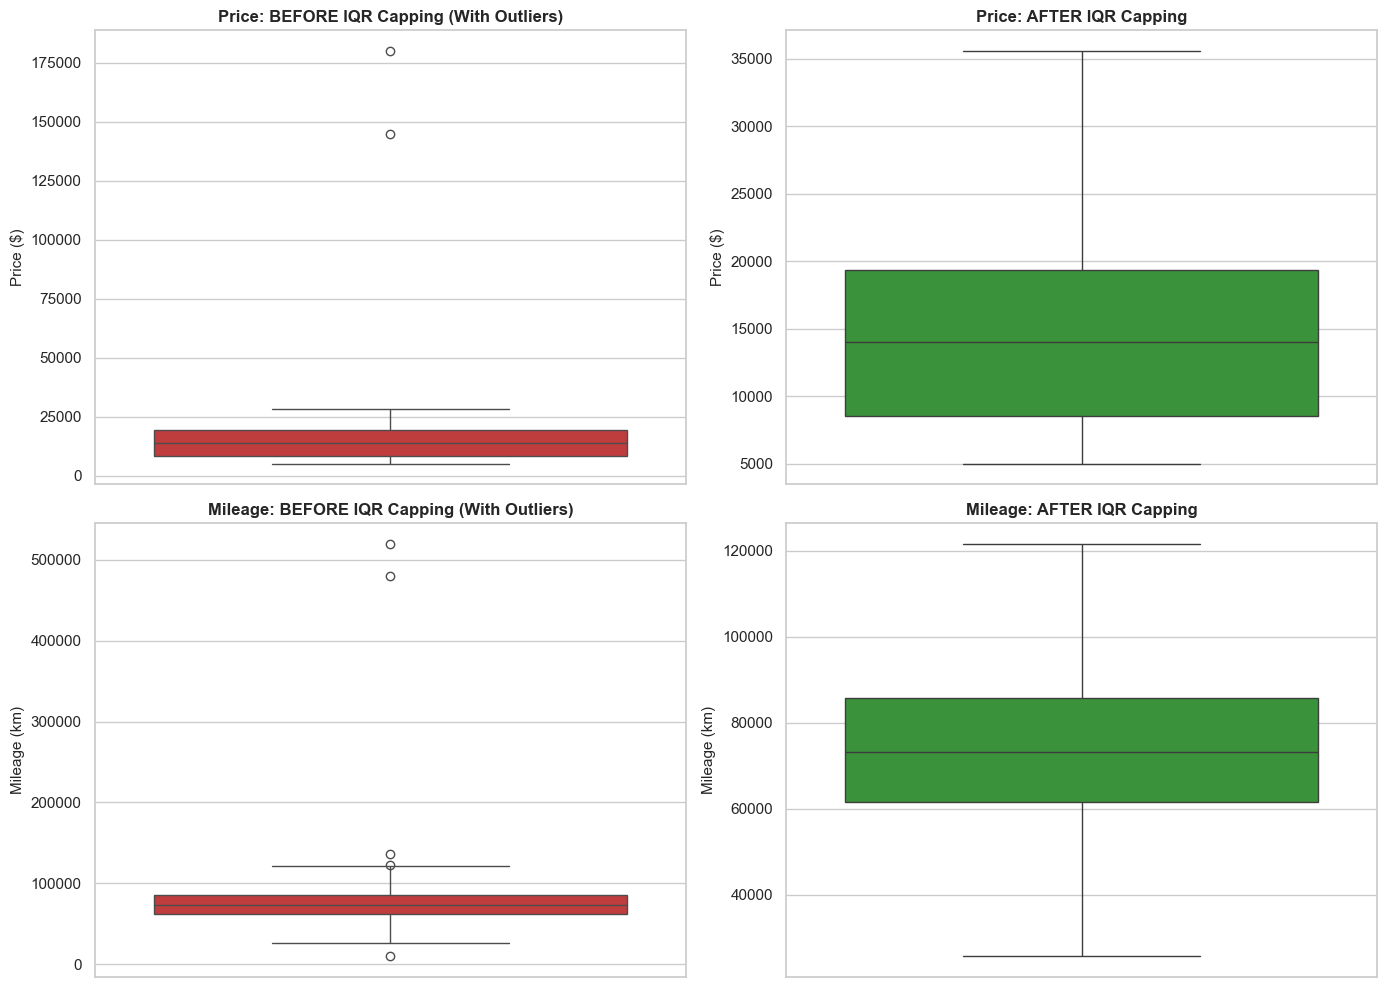

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price Before vs After
sns.boxplot(y=df_imputed['price'], color='#d62728', ax=axes[0, 0])
axes[0, 0].set_title("Price: BEFORE IQR Capping (With Outliers)", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Price ($)", fontsize=11)

sns.boxplot(y=df_capped['price'], color='#2ca02c', ax=axes[0, 1])
axes[0, 1].set_title("Price: AFTER IQR Capping", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Price ($)", fontsize=11)

# 2. Mileage Before vs After
sns.boxplot(y=df_imputed['mileage_km'], color='#d62728', ax=axes[1, 0])
axes[1, 0].set_title("Mileage: BEFORE IQR Capping (With Outliers)", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Mileage (km)", fontsize=11)

sns.boxplot(y=df_capped['mileage_km'], color='#2ca02c', ax=axes[1, 1])
axes[1, 1].set_title("Mileage: AFTER IQR Capping", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Mileage (km)", fontsize=11)

plt.tight_layout()
plt.show()

### 9. One-Hot Encoding of Categorical Feature
Encode the categorical `fuel_type` feature using `OneHotEncoder(drop='first', sparse_output=False)` to convert nominal text labels into binary indicator vectors suitable for machine learning models.


In [9]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_fuel_array = ohe.fit_transform(df_capped[['fuel_type']])
encoded_fuel_df = pd.DataFrame(
    encoded_fuel_array,
    columns=ohe.get_feature_names_out(['fuel_type'])
)

print("One-Hot Encoded Columns:")
print(encoded_fuel_df.head())

One-Hot Encoded Columns:
   fuel_type_Electric  fuel_type_Petrol
0                 0.0               1.0
1                 1.0               0.0
2                 0.0               0.0
3                 1.0               0.0
4                 0.0               0.0


### 10. Feature Standardization using StandardScaler
Apply `StandardScaler` to transform numeric features (`mileage_km`, `age_years`, `engine_size_L`, `price`) to zero mean ($\mu = 0$) and unit variance ($\sigma^2 = 1$).


In [10]:
scaler = StandardScaler()
scaled_numeric_array = scaler.fit_transform(df_capped[numeric_cols])
scaled_numeric_df = pd.DataFrame(scaled_numeric_array, columns=numeric_cols)

print("Standardized Numeric Features Summary (Mean ≈ 0, Std ≈ 1):")
print(scaled_numeric_df.describe().round(4))

Standardized Numeric Features Summary (Mean ≈ 0, Std ≈ 1):
       mileage_km  age_years  engine_size_L     price
count    120.0000   120.0000       120.0000  120.0000
mean       0.0000     0.0000         0.0000   -0.0000
std        1.0042     1.0042         1.0042    1.0042
min       -2.1480    -1.4389        -1.2618   -1.3195
25%       -0.5458    -0.9265        -0.8177   -0.8237
50%       -0.0328    -0.1580        -0.0777   -0.0478
75%        0.5223     0.6106         0.6623    0.7074
max        2.1244     1.8915         1.4024    3.0039


### 11. Final Model-Ready DataFrame Creation
Concatenate scaled numeric features and one-hot encoded categorical features into a single final DataFrame named `processed_df`.


In [11]:
# Combine scaled numeric and encoded categorical dataframes
processed_df = pd.concat([scaled_numeric_df, encoded_fuel_df], axis=1)

print("--- Final Model-Ready DataFrame (`processed_df`) ---")
print("Shape (Rows, Columns):", processed_df.shape)
print("\nColumn Data Types:")
print(processed_df.dtypes)

print("\nMissing Values Check:", processed_df.isna().sum().sum())
assert processed_df.isna().sum().sum() == 0, "Error: Missing values found in processed_df!"
assert all(np.issubdtype(dtype, np.number) for dtype in processed_df.dtypes), "Error: Non-numeric columns remain!"

print("\nFirst 5 rows of `processed_df`:")
processed_df.head()

--- Final Model-Ready DataFrame (`processed_df`) ---
Shape (Rows, Columns): (120, 6)

Column Data Types:
mileage_km            float64
age_years             float64
engine_size_L         float64
price                 float64
fuel_type_Electric    float64
fuel_type_Petrol      float64
dtype: object

Missing Values Check: 0

First 5 rows of `processed_df`:


,mileage_km,age_years,engine_size_L,price,fuel_type_Electric,fuel_type_Petrol
0,0.599538,1.122958,-0.077704,-1.319545,0.0,1.0
1,-0.106472,-1.438923,-0.077704,0.609074,1.0,0.0
2,0.767398,-0.157983,-0.817739,-0.639019,0.0,0.0
3,-0.032809,0.354394,1.402367,-0.717463,1.0,0.0
4,-0.213086,-0.414171,-1.261761,0.176194,0.0,0.0


### 12. Result & Conclusion

#### Summary of Preprocessing Achievements
1. **Missing Value Imputation:** All missing entries across numeric (`mileage_km`, `age_years`, `price`) and categorical (`fuel_type`) attributes were completely resolved using median and mode imputation, preserving 100% of data rows.
2. **Outlier Treatment:** Extreme price and mileage outliers were detected via IQR bounds ($1.5 \times IQR$) and capped successfully without dropping data points.
3. **Categorical Encoding:** `fuel_type` was converted into binary indicator variables using nominal one-hot encoding (`drop='first'`).
4. **Standardization:** All continuous numeric attributes were transformed to standard scale ($\mu = 0, \sigma = 1$).
5. **Model Readiness:** The final `processed_df` DataFrame (120 rows × 6 columns) contains exclusively numeric data with zero missing values, fully prepared for downstream machine learning algorithms.
